In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/cars_ford_cleaned.csv')
df

,model_year,milage,engine,accident,price,automatic
0,2013,51000.0,3.7,1,10300.0,0.0
1,2023,2823.0,3.5,0,58504.0,1.0
2,2014,37060.0,5.0,0,28500.0,0.0
3,2013,105000.0,3.7,1,6600.0,0.0
4,2015,194454.0,2.5,0,9888.0,0.0
...,...,...,...,...,...,...
331,2011,153818.0,6.7,1,29800.0,0.0
332,2022,17000.0,2.7,0,69999.0,0.0
333,2019,106000.0,2.0,1,12000.0,0.0
334,2018,65441.0,2.7,0,38000.0,0.0


In [4]:
df.isnull().sum()

,0
model_year,0
milage,0
engine,0
accident,0
price,0
automatic,0


In [ ]:
df.dropna(inplace=True)

# CORRELACIONES

In [5]:
corr_matrix = df.corr()
corr_charges = corr_matrix['price']
corr_charges.sort_values(ascending=False)

,price
price,1.000000
model_year,0.662479
engine,0.199899
automatic,0.098148
accident,-0.199927
milage,-0.637557


<Axes: >

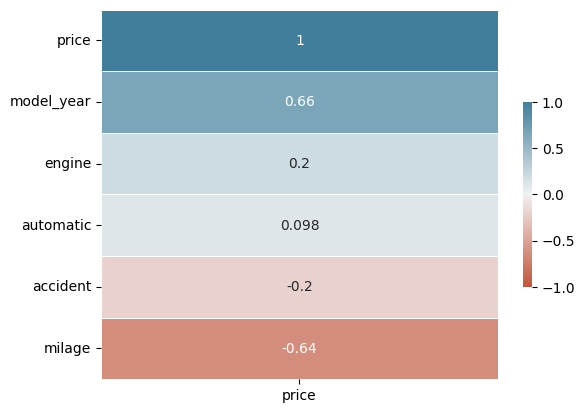

In [6]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [7]:
# prompt: crea una variable X que tenga todas las columnas menos price del dataframe df y otra variable y que solo tenga la columna price

X = df.drop('price', axis=1).values
y = df['price'].values

# DIVIDIMOS EL DATASET EN ENTRENAMIENTO Y PRUEBA

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# ESCALAMOS LOS DATOS

In [9]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.fit_transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train.reshape(-1, 1))
y_test = sc_y.fit_transform(y_test.reshape(-1, 1))

# CREAMOS Y ENTRENAMOS EL MODELO DE REGRESION LINEAL

In [10]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

# EVALUAMOS EL MODELO

In [11]:
import sklearn.metrics as metrics
#erro cuadratico medio
mse = metrics.mean_squared_error(y_test,y_pred)
#R2 Coeficiente de determinación
r2 = metrics.r2_score(y_test,y_pred)

print(f'El error cuadratico medio(MSE) es de {round(mse,4)}')
print(f'El coeficiente de determinación(R2) es de {round(r2,4)}')

El error cuadratico medio(MSE) es de 0.243
El coeficiente de determinación(R2) es de 0.757


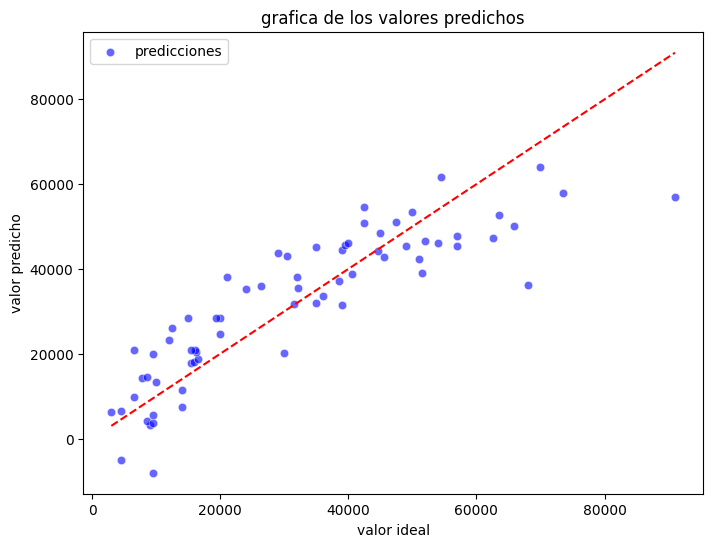

In [12]:
y_test_inv = sc_y.inverse_transform(y_test)
y_pred_inv = sc_y.inverse_transform(y_pred)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_inv.flatten(),y=y_pred_inv.flatten(),alpha=0.6,color='blue',label='predicciones')
plt.plot([min(y_test_inv),max(y_test_inv)],[min(y_test_inv),max(y_test_inv)],color='red',linestyle='--')

plt.xlabel("valor ideal")
plt.ylabel("valor predicho")
plt.title("grafica de los valores predichos")
plt.legend()
plt.show()

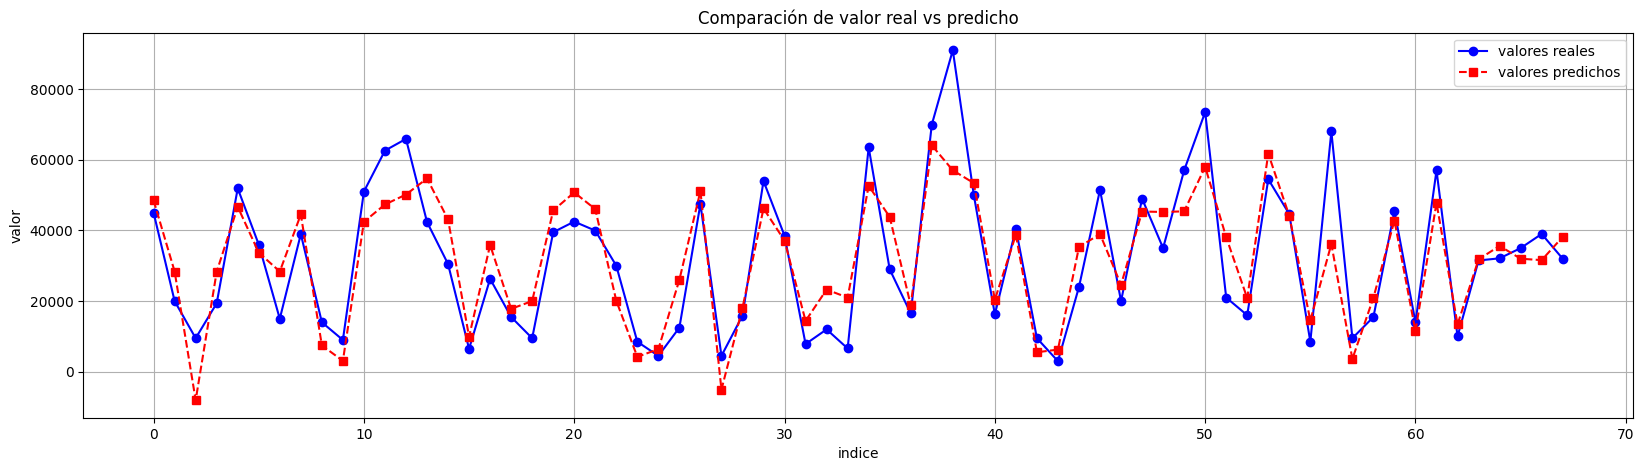

In [13]:

y_test_inv = sc_y.inverse_transform(y_test)
y_pred_inv = sc_y.inverse_transform(y_pred)


plt.figure(figsize=(20,5))
plt.plot(y_test_inv.flatten(),label='valores reales',marker='o',linestyle='-',color='blue')
plt.plot(y_pred_inv.flatten(),label='valores predichos',marker='s',linestyle='--',color='red')


plt.xlabel("indice")
plt.ylabel("valor")
plt.title("Comparación de valor real vs predicho")
plt.legend()
plt.grid(True)
plt.show()